# NBA Rules RAG — Colab Walkthrough

**Multimodal officiating analysis**: YouTube clip → frame extraction → VLM narration → RAG over the NBA rulebook → structured ruling with explicit rule citations.

### Pipeline

```
YouTube URL + start/end timestamps + question
              ↓
  1. Frame extraction      (yt-dlp + OpenCV, 5–10 keyframes)
              ↓
  2. Rulebook index        (auto-built from PDF if missing, FAISS + BAAI/bge-small-en-v1.5)
              ↓
  3. VLM narration         (any OpenAI-compatible vision model → structured JSON)
              ↓
  4. VLM output embedding  (embed narration for downstream similarity use)
              ↓
  5. Query building        (VLM output + question → dense retrieval query)
              ↓
  6. FAISS retrieval       (top-5 rulebook chunks by semantic similarity)
              ↓
  7. Automated reasoning   (OpenAI-compatible endpoint → structured JSON ruling)
              ↓
  Verdict + applicable rules + reasoning + confidence + limitations
```

**Two modes:**
- **`DEMO_MODE = True`** — uses a built-in clip with pre-saved frames and a mock VLM response. No API key required.
- **`DEMO_MODE = False`** — downloads a real YouTube clip, calls your vision model, and generates an automated ruling. Requires `OPENAI_API_KEY`, `VLM_MODEL`, and `REASONER_MODEL`.

> Run cells top-to-bottom. GPU runtime is optional — embeddings run on CPU.

## Setup

Run this once per fresh Colab runtime to clone the repository and install all Python dependencies.

In [15]:
import pathlib, os

# ── Repository location ───────────────────────────────────────────────────────
REPO_URL = "https://github.com/jmehami1/nba-rules-rag.git"
REPO_DIR = pathlib.Path("/content/nba-rules-rag")

# ── System dependencies ───────────────────────────────────────────────────────
!apt-get install -qq git ffmpeg

# ── Clone repository ──────────────────────────────────────────────────────────
if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"✓ Repo already present at {REPO_DIR}")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

# ── Python dependencies ───────────────────────────────────────────────────────
!pip install -q -e .

# ── Quick demo-frame check ────────────────────────────────────────────────────
demo_dir = REPO_DIR / "data" / "processed" / "demo_frames"
demo_jpgs = sorted(demo_dir.glob("frame_*.jpg"))
print(f"Demo frame directory: {demo_dir}")
print(f"Demo frame count    : {len(demo_jpgs)}")

print("\n✓ Setup complete")

✓ Repo already present at /content/nba-rules-rag
Working directory: /content/nba-rules-rag
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for nba-rules-rag (pyproject.toml) ... done
Demo frame directory: /content/nba-rules-rag/data/processed/demo_frames
Demo frame count    : 8

✓ Setup complete


## 0 — User Configuration (edit this section only)

All required inputs are centralized in the next code cell.

Input groups and expected formats:
- **Run mode:**
  - `DEMO_MODE` — `True` for offline demo (no API calls), `False` for live end-to-end.
  - `CONFIRM_API_CALLS` — must be `True` in live mode to authorise paid API usage.
- **Live clip inputs** (ignored when `DEMO_MODE = True`):
  - `YOUTUBE_URL` — full YouTube URL.
  - `START_TIME` / `END_TIME` — clip bounds, format: `SS`, `MM:SS`, or `HH:MM:SS`.
  - `QUESTION` — natural-language officiating question about the play.
  - `N_FRAMES` — target keyframe count; extractor clamps to 5–10.
- **API + models** (required for live mode):
  - `OPENAI_API_KEY_FALLBACK` — optional; prefer Colab Secrets (🔑 panel) instead.
  - `VLM_MODEL` / `REASONER_MODEL` — model IDs for vision and reasoning stages.
- **Paths** (defaults match the repo layout):
  - `PDF_PATH` — NBA rulebook PDF; repo-local or mounted Drive path.
  - `OUTPUT_DIR` / `VECTOR_STORE_DIR` — artifact output locations.

In [16]:
import pathlib

# =====================
# RUN MODE
# =====================
DEMO_MODE         = True   # True: demo-only, no API calls. False: live end-to-end.
CONFIRM_API_CALLS = False  # Set True to authorise paid API calls in live mode.

# =====================
# LIVE CLIP INPUTS  (ignored when DEMO_MODE = True)
# =====================
YOUTUBE_URL = "https://www.youtube.com/watch?v=9fFWawcJXUw"
START_TIME  = "0:21"   # Formats: SS | MM:SS | HH:MM:SS
END_TIME    = "0:29"   # Must be after START_TIME
QUESTION    = "Was the player in the blue uniform traveling?"
N_FRAMES    = 8        # Target only; extractor clamps to [5, 10]

# =====================
# API + MODELS  (required for live mode)
# =====================
OPENAI_API_KEY_FALLBACK = ""   # Optional — prefer Colab Secrets (🔑 panel)
VLM_MODEL      = "gpt-5.5"
REASONER_MODEL = "gpt-5.5"

# =====================
# PATHS  (default to repo layout; REPO_DIR set in Setup above)
# =====================
PDF_PATH = pathlib.Path("docs/2023-24-NBA-Season-Official-Playing-Rules.pdf")

OUTPUT_DIR       = str((REPO_DIR / "data" / "processed").resolve())
VECTOR_STORE_DIR = str((REPO_DIR / "data" / "vector_store").resolve())

print("Configuration loaded.")
print(f"Mode     : {'DEMO' if DEMO_MODE else 'LIVE'}")
print(f"Clip     : {YOUTUBE_URL}  {START_TIME} -> {END_TIME}")
print(f"Question : {QUESTION}")

Configuration loaded.
Mode     : DEMO
Clip     : https://www.youtube.com/watch?v=9fFWawcJXUw  0:21 -> 0:29
Question : Was the player in the blue uniform traveling?


## 1 — API keys and model loading

This cell loads API keys from Colab Secrets and applies model IDs from Section 0.

Expected keys for live mode:
- OPENAI_API_KEY (preferred)
- or HF_TOKEN for compatible endpoints

Tip:
- Keep OPENAI_API_KEY_FALLBACK empty if you are using Colab Secrets.

In [17]:
import os

# ── Load from Colab Secrets (preferred) ───────────────────────────────────────
try:
    from google.colab import userdata
    for _key in ("OPENAI_API_KEY", "HF_TOKEN"):
        try:
            _val = userdata.get(_key)
            if _val:
                os.environ[_key] = _val
        except Exception:
            pass
except ImportError:
    pass  # not running in Colab

# ── Optional fallback from top config cell ────────────────────────────────────
if not os.environ.get("OPENAI_API_KEY") and OPENAI_API_KEY_FALLBACK.strip():
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY_FALLBACK.strip()

# Models come from the top config cell.
os.environ["VLM_MODEL"] = VLM_MODEL
os.environ["REASONER_MODEL"] = REASONER_MODEL

# ── Summary ───────────────────────────────────────────────────────────────────
api_key_ok = bool(os.environ.get("OPENAI_API_KEY") or os.environ.get("HF_TOKEN"))
print(f"API key set        : {'✓' if api_key_ok else '✗'}")
print(f"VLM_MODEL          : {os.environ.get('VLM_MODEL', '(not set)')}")
print(f"REASONER_MODEL     : {os.environ.get('REASONER_MODEL', '(not set)')}")
if not DEMO_MODE and not api_key_ok:
    print("⚠ Live mode requires OPENAI_API_KEY (or compatible token).")

API key set        : ✗
VLM_MODEL          : gpt-5.5
REASONER_MODEL     : gpt-5.5


## 2 — Rulebook PDF validation

This cell validates PDF_PATH from Section 0.

Expected input:
- PDF_PATH points to the NBA rulebook PDF.
- It can be relative to the repo or an absolute path (for example, mounted Drive).

Notes:
- Demo mode can run without rebuilding the index.
- Live mode may need this file if the vector store is missing.

In [18]:
import pathlib

# This section validates the PDF path configured in Section 0.
# If you upload or mount a PDF, update PDF_PATH in Section 0 and re-run it.

pdf_abs = PDF_PATH if PDF_PATH.is_absolute() else (REPO_DIR / PDF_PATH)
pdf_abs = pdf_abs.resolve()

print(f"Configured PDF_PATH : {PDF_PATH}")
print(f"Resolved PDF path   : {pdf_abs}")
print(f"Exists              : {pdf_abs.exists()}")

if not pdf_abs.exists() and not DEMO_MODE:
    print("\n⚠ PDF not found. Live mode may fail when building the rulebook index.")
    print("  Use a valid path in the top configuration cell (Section 0).")

# Keep a resolved path for downstream cells.
PDF_PATH = pdf_abs

Configured PDF_PATH : docs/2023-24-NBA-Season-Official-Playing-Rules.pdf
Resolved PDF path   : /content/nba-rules-rag/docs/2023-24-NBA-Season-Official-Playing-Rules.pdf
Exists              : True


## 3 — Run input review

No edits needed here. This section only prints and normalizes values from Section 0 so you can confirm everything before execution.

In [19]:
# Inputs are now centralized in Section 0.
# This cell prints a run-ready summary so you can verify settings before execution.

RULEBOOK_PDF_PATH = str(PDF_PATH)
OUTPUT_DIR = str(pathlib.Path(OUTPUT_DIR).resolve())
VECTOR_STORE_DIR = str(pathlib.Path(VECTOR_STORE_DIR).resolve())

print(f"Mode           : {'DEMO (no API calls)' if DEMO_MODE else 'LIVE'}")
print(f"YouTube URL    : {YOUTUBE_URL}")
print(f"Interval       : {START_TIME} -> {END_TIME}")
print(f"Question       : {QUESTION}")
print(f"Frames         : {N_FRAMES}")
print(f"API calls auth : {'✓' if CONFIRM_API_CALLS else '✗ (live mode blocked)'}")
print(f"Output dir     : {OUTPUT_DIR}")
print(f"Vector store   : {VECTOR_STORE_DIR}")
print(f"Rulebook PDF   : {RULEBOOK_PDF_PATH}")

Mode           : DEMO (no API calls)
YouTube URL    : https://www.youtube.com/watch?v=9fFWawcJXUw
Interval       : 0:21 -> 0:29
Question       : Was the player in the blue uniform traveling?
Frames         : 8
API calls auth : ✗ (live mode blocked)
Output dir     : /content/nba-rules-rag/data/processed
Vector store   : /content/nba-rules-rag/data/vector_store
Rulebook PDF   : /content/nba-rules-rag/docs/2023-24-NBA-Season-Official-Playing-Rules.pdf


## 4 — Run the full pipeline

This cell loads `run_nba_query.py` directly and executes the complete pipeline in one call.  
The result dictionary is used by all display cells below.

Steps run automatically:
1. Build (or load) the FAISS rulebook index
2. Extract keyframes from the YouTube clip (live) or load pre-saved frames (demo)
3. Call the VLM to narrate the play
4. Embed the VLM narration
5. Build a retrieval query and fetch the top-5 rulebook chunks
6. Call the reasoning model for a structured ruling

In [20]:
import argparse, importlib.util, pathlib, sys

# ── Load run_nba_query.py as a module so __file__ resolves correctly ──────────
_script_path = pathlib.Path("scripts/run_nba_query.py").resolve()
_spec = importlib.util.spec_from_file_location("run_nba_query", _script_path)
rnq = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(rnq)

# ── Patch interactive confirmation for notebook environments ──────────────────
# The script's confirm_live_api_charge_warning() raises when stdin is not a tty
# (which is always the case in Colab). We replace it with the user-set flag.
rnq.confirm_live_api_charge_warning = lambda: CONFIRM_API_CALLS

# ── Ensure demo frames exist when running demo mode ───────────────────────────
if DEMO_MODE:
    demo_dir = pathlib.Path(rnq.DEFAULT_DEMO_FRAMES_DIR)
    demo_jpgs = sorted(demo_dir.glob("frame_*.jpg"))
    if not demo_jpgs:
        raise FileNotFoundError(
            f"No demo frames found in {demo_dir}. "
            "Re-run Section 0 (setup) so git-lfs assets are pulled, "
            "or switch DEMO_MODE=False and run live mode."
        )

# ── Build argument namespace ──────────────────────────────────────────────────
args = argparse.Namespace(
    youtube_url      = YOUTUBE_URL,
    start_time       = START_TIME,
    end_time         = END_TIME,
    question         = QUESTION,
    n_frames         = N_FRAMES,
    output_dir       = OUTPUT_DIR,
    no_show          = True,           # suppress blocking plt.show(); we display inline
    demo             = DEMO_MODE,
    rulebook_pdf_path= RULEBOOK_PDF_PATH,
    vector_store_dir = VECTOR_STORE_DIR,
)

# ── Execute ───────────────────────────────────────────────────────────────────
print("Starting NBA Rules RAG pipeline...\n")
result = rnq.run_nba_query(args)
print("\n✓ Pipeline complete")

Starting NBA Rules RAG pipeline...


✓ Pipeline complete


## 5 — Keyframes

Frames extracted : 8
Interval         : 0:21 → 0:29
Timestamps (s)   : [21.0, 22.14, 23.29, 24.43, 25.57, 26.71, 27.86, 29.0]
Output dir       : /content/nba-rules-rag/data/processed/demo_frames


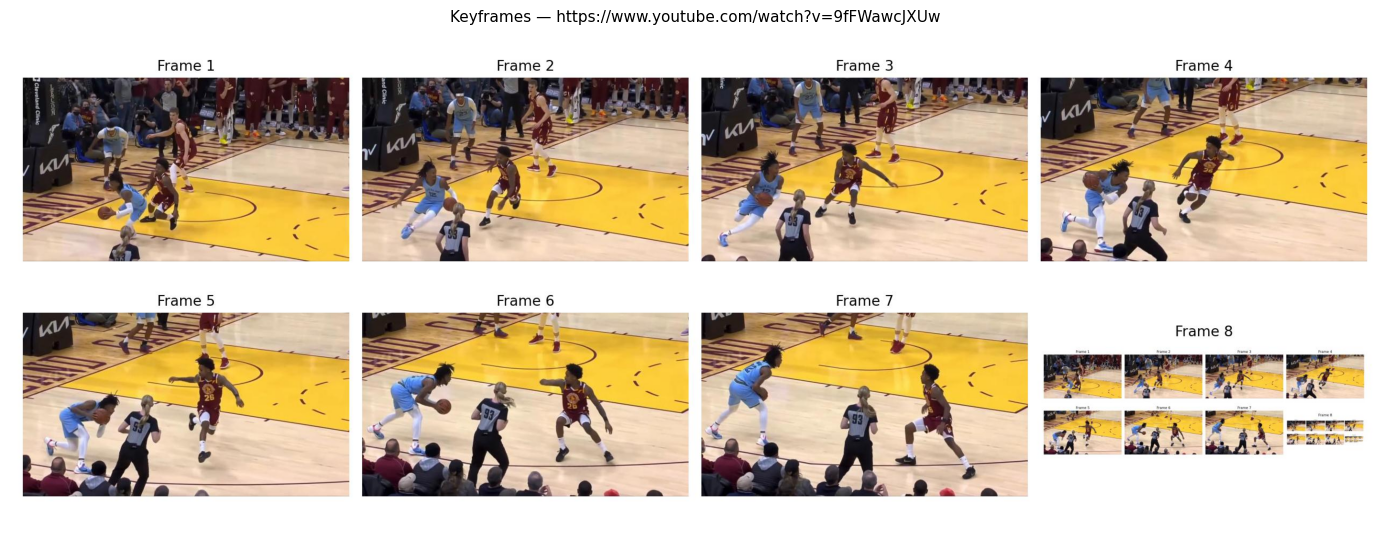

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print(f"Frames extracted : {result['n_frames']}")
print(f"Interval         : {result['start_time']} → {result['end_time']}")
print(f"Timestamps (s)   : {[round(t, 2) for t in result['frame_timestamps_sec']]}")
print(f"Output dir       : {result['output_dir']}")

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(mpimg.imread(result["grid_path"]))
ax.set_title(f"Keyframes — {result['youtube_url']}", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

## 6 — Rulebook index

In [22]:
store = result["rulebook_embedding_store"]
built = store.get("built", False)
print(f"Status    : {'built this run' if built else 'loaded from cache'}")
print(f"Store dir : {store.get('vector_store_dir')}")
if built:
    print(f"PDF source: {store.get('pdf_path')}")

Status    : loaded from cache
Store dir : /content/nba-rules-rag/data/vector_store


## 7 — VLM narration output

In [23]:
import json

if result.get("vlm_error"):
    print(f"✗  VLM error: {result['vlm_error']}")
elif result.get("vlm_result") is None:
    print("VLM was skipped (API calls not authorised).")
else:
    vlm = result["vlm_result"]

    print("=" * 72)
    print("VLM NARRATION")
    print("=" * 72)

    print("\nPlay narration:")
    print(vlm.get("play_narration", "(none)"))

    obs = vlm.get("frame_observations", [])
    if obs:
        print(f"\nPer-frame observations ({len(obs)} frames):")
        for fo in obs:
            print(f"\n  [{fo.get('frame_id', '?')}]  t={fo.get('timestamp_sec', '?')}s")
            print(f"  {fo.get('description', '').strip()}")

    signals = vlm.get("query_relevant_signals", [])
    if signals:
        print("\nQuery-relevant signals:")
        for s in signals:
            print(f"  • {s}")

    uncertainties = vlm.get("uncertainties", [])
    if uncertainties:
        print("\nUncertainties:")
        for u in uncertainties:
            print(f"  • {u}")

    emb = result.get("vlm_embedding")
    if emb:
        print(f"\nVLM embedding: dim={emb['vlm_embedding_dim']}, saved to {emb['vlm_embedding_path']}")
    elif result.get("vlm_embedding_error"):
        print(f"\n⚠  VLM embedding error: {result['vlm_embedding_error']}")

VLM NARRATION

Play narration:
The player in blue moves left toward the sideline while controlling the ball low with the left hand in the opening frames. Across F01 to F02, the ball appears consistent with an active dribble or the end of a dribble. By F03, the player appears to bring the ball into two-hand control near the chest, and from F03 through F07 the ball remains held rather than visibly dribbled. After that apparent gather, the player continues to lean and reposition near the sideline, then settles into a stationary stance facing the defender. This sequence is relevant to the travelling question because the play appears to transition from dribble to held ball, but the sampled frames do not clearly show the exact gather moment or every foot contact needed to determine a definitive travelling violation from the images alone.

Per-frame observations (7 frames):

  [F01]  t=21.0s
  The blue player is moving leftward near the sideline with the ball low on the left side of the body.

## 8 — Copy-paste reasoning prompt

The full prompt sent (or ready to be sent) to the reasoning model.  
You can paste this directly into ChatGPT or any OpenAI-compatible interface for manual review.

In [24]:
print(rnq.build_reasoning_prompt(result.get("vlm_result"), result.get("rag_chunks")))

You are an expert NBA rules official. Use only the provided play description and rulebook excerpts.
Do not infer unseen foot contacts between frames.
If the evidence is insufficient to establish a violation, say the play is inconclusive rather than guessing.

Question: Was there enough visible evidence to rule this a travelling violation under the NBA rules?

Decision standard:
- A travelling violation should only be called if the visible evidence clearly establishes the gather point and an illegal foot movement after the gather.
- If the gather point, pivot foot, or post-gather foot contacts are ambiguous, do not call a violation.
- Distinguish between:
  1. "No travel observed"
  2. "Travel observed"
  3. "Inconclusive / cannot determine from provided frames"

Required analysis:
1. Identify the most likely gather frame and explain why using Rule 4, Section III.
2. Identify whether the player is progressing or stationary at gather.
3. Identify the first and second step after gather un

## 9 — Rule retrieval (RAG)

In [25]:
print(f"Retrieval query:\n  {result.get('rag_query', '(none)')}\n")

if result.get("rag_error"):
    print(f"✗  RAG error: {result['rag_error']}")
elif not result.get("rag_chunks"):
    print("No chunks retrieved.")
else:
    chunks = result["rag_chunks"]
    print(f"Retrieved {len(chunks)} chunk(s):\n")
    for i, chunk in enumerate(chunks, 1):
        rule_id = chunk.get("rule_id", "")
        title   = chunk.get("section_title", "")
        score   = chunk.get("score", 0)
        text    = chunk.get("text", "")[:400]
        print(f"[{i}]  Rule {rule_id} — {title}  (similarity: {score:.4f})")
        print(f"     {text}…")
        print()

Retrieval query:
  Was this player in blue uniform travelling? The player in blue moves left toward the sideline while controlling the ball low with the left hand in the opening frames. Across F01 to F02, the ball appears consistent with an active dribble or the end of a dribble. By F03, the player appears to bring the ball into two-hand control near the chest, and from F03 through F07 the ball remains held rather than visibly dribbled. After that apparent gather, the player continues to lean and reposition near the sideline, then settles into a stationary stance facing the defender. This sequence is relevant to the travelling question because the play appears to transition from dribble to held ball, but the sampled frames do not clearly show the exact gather moment or every foot contact needed to determine a definitive travelling violation from the images alone. The ball appears low and left-sided in F01-F02, consistent with a live dribble or the end of a dribble. By F03, the ball app

## 10 — Final ruling &amp; status report

In [26]:
if result.get("ruling_error"):
    print(f"✗  Ruling error: {result['ruling_error']}")
elif not result.get("ruling"):
    print("Ruling was skipped (API calls not authorised).")
else:
    ruling = result["ruling"]

    verdict    = ruling.get("travel_ruling", "unknown").upper()
    confidence = ruling.get("ruling_confidence", "unknown")
    gather     = ruling.get("likely_gather_frame", "unclear")
    g_conf     = ruling.get("gather_confidence", "unknown")
    steps      = ruling.get("post_gather_step_count_visible", "unclear")
    pivot      = ruling.get("pivot_foot", "unclear")

    VERDICT_ICON = {"TRAVEL": "🚨", "NO_TRAVEL": "✅", "INCONCLUSIVE": "❔"}.get(verdict, "❔")
    CONF_ICON    = {"high": "●●●", "medium": "●●○", "low": "●○○"}.get(confidence, "○○○")

    sep  = "═" * 72
    thin = "─" * 72

    # ── Verdict banner ────────────────────────────────────────────────────────
    print(sep)
    print(f"  FINAL RULING")
    print(thin)
    print(f"  {VERDICT_ICON}  {verdict}")
    print(f"  Ruling confidence  : {confidence.upper()}  {CONF_ICON}")
    print(sep)

    # ── Key play facts ────────────────────────────────────────────────────────
    print("\n  KEY PLAY FACTS")
    print(thin)
    print(f"  Likely gather frame        : {gather}  (confidence: {g_conf})")
    print(f"  Post-gather steps visible  : {steps}")
    print(f"  Pivot foot                 : {pivot}")

    # ── Applicable rules ──────────────────────────────────────────────────────
    applicable = ruling.get("applicable_rules", [])
    if applicable:
        print(f"\n  APPLICABLE RULES ({len(applicable)})")
        print(thin)
        for rule in applicable:
            print(f"  ▸ {rule.get('rule', '')}")
            application = rule.get("application", "").strip()
            # Wrap application text at ~66 chars for readability
            words = application.split()
            line, lines = [], []
            for word in words:
                if sum(len(w) + 1 for w in line) + len(word) > 66:
                    lines.append(" ".join(line))
                    line = [word]
                else:
                    line.append(word)
            if line:
                lines.append(" ".join(line))
            for l in lines:
                print(f"    {l}")
            print()

    # ── Reasoning ─────────────────────────────────────────────────────────────
    reasoning = ruling.get("reasoning", "").strip()
    if reasoning:
        print("  REASONING")
        print(thin)
        words = reasoning.split()
        line, lines = [], []
        for word in words:
            if sum(len(w) + 1 for w in line) + len(word) > 66:
                lines.append(" ".join(line))
                line = [word]
            else:
                line.append(word)
        if line:
            lines.append(" ".join(line))
        for l in lines:
            print(f"  {l}")

    # ── Facts required ────────────────────────────────────────────────────────
    facts = ruling.get("facts_required_for_travel_call", [])
    if facts:
        print(f"\n  FACTS REQUIRED FOR A TRAVEL CALL ({len(facts)})")
        print(thin)
        for f in facts:
            print(f"  • {f}")

    # ── Limitations ───────────────────────────────────────────────────────────
    limitations = ruling.get("limitations", [])
    if limitations:
        print(f"\n  LIMITATIONS ({len(limitations)})")
        print(thin)
        for lim in limitations:
            print(f"  ⚠  {lim}")

    print(f"\n{sep}")

rows = [
    ("Rulebook index",
     bool(result.get("rulebook_embedding_store")),
     "ready"),
    ("Frame extraction",
     result.get("n_frames", 0) > 0,
     f"{result.get('n_frames', 0)} frames"),
    ("API authorised",
     result.get("api_call_authorized", False),
     "yes" if result.get("api_call_authorized") else "no / demo mode"),
    ("VLM narration",
     result.get("vlm_result") is not None,
     "completed" if result.get("vlm_result") else str(result.get("vlm_error") or "skipped")),
    ("VLM embedding",
     result.get("vlm_embedding") is not None,
     "completed" if result.get("vlm_embedding") else str(result.get("vlm_embedding_error") or "skipped")),
    ("Rule retrieval",
     result.get("rag_chunks") is not None,
     (f"{len(result['rag_chunks'])} chunks" if result.get("rag_chunks")
      else str(result.get("rag_error") or "skipped"))),
    ("Final ruling",
     result.get("ruling") is not None,
     "completed" if result.get("ruling") else str(result.get("ruling_error") or "skipped")),
]

print("=" * 72)
print("  STATUS REPORT")
print("=" * 72)
for label, ok, detail in rows:
    icon = "✓" if ok else "✗"
    print(f"  {icon}  {label:<22}  {detail}")
print("=" * 72)

════════════════════════════════════════════════════════════════════════
  FINAL RULING
────────────────────────────────────────────────────────────────────────
  ❔  INCONCLUSIVE
  Ruling confidence  : MEDIUM  ●●○
════════════════════════════════════════════════════════════════════════

  KEY PLAY FACTS
────────────────────────────────────────────────────────────────────────
  Likely gather frame        : F03  (confidence: medium)
  Post-gather steps visible  : unclear
  Pivot foot                 : unclear

  APPLICABLE RULES (2)
────────────────────────────────────────────────────────────────────────
  ▸ Rule 4, Section III(b)
    For a dribbler, the gather occurs when the player puts two hands
    on the ball, lets the ball come to rest, puts a hand under the
    ball and pauses it, or otherwise gains enough control to hold,
    pass, shoot, change hands, or cradle the ball. Based on the play
    description, F03 is the most likely gather frame because the ball
    appears to come i